# LineWorld Benchmark: A2C/PPO vs Shielded A2C/PPO

This notebook trains and compares four variants on `LineWorldSafety-v0`:
- A2C
- PPO
- Shielded A2C
- Shielded PPO

It plots:
- Training reward curve (episode return)
- Training safety curve (unsafe termination rate)


In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from stable_baselines3 import A2C, PPO
from stable_baselines3.common.callbacks import BaseCallback

from pls.algorithms.a2c_shielded import A2C_shielded
from pls.algorithms.ppo_shielded import PPO_shielded
from pls.sensors.rule_based import RuleBasedSensorModel
from pls.sensors.mlp import PretrainedLineWorldMLPSensorModel
from pls.envs.line_world import LineWorldSafetyEnv


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
TOTAL_TIMESTEPS = 6_000
SEEDS = [0, 1, 2]
WINDOW = 20
ENV_LENGTH = 7
ENV_MAX_STEPS = 30
SHIELD_ALPHA = 0.2
def resolve_shield_program():
    candidates = [
        Path.cwd() / 'examples' / 'train_a_policy' / 'data' / 'lineworld_safety.pl',
        Path.cwd() / 'train_a_policy' / 'data' / 'lineworld_safety.pl',
        Path.cwd().parent / 'examples' / 'train_a_policy' / 'data' / 'lineworld_safety.pl',
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError('Could not find lineworld_safety.pl from current notebook working directory')

PROGRAM = resolve_shield_program()

plt.style.use('ggplot')

def resolve_mlp_sensor_ckpt():
    candidates = [
        Path.cwd() / 'examples' / 'pretrain_sensors_lineworld' / 'lineworld_mlp_sensor.pt',
        Path.cwd() / 'pretrain_sensors_lineworld' / 'lineworld_mlp_sensor.pt',
        Path.cwd().parent / 'examples' / 'pretrain_sensors_lineworld' / 'lineworld_mlp_sensor.pt',
    ]
    for path in candidates:
        if path.exists():
            return path.resolve()
    raise FileNotFoundError('Could not find lineworld_mlp_sensor.pt from current notebook working directory')

MLP_SENSOR_CKPT = resolve_mlp_sensor_ckpt()


In [3]:
class SafetyRewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_unsafe = []
        self.episode_end_steps = []

    def _on_step(self) -> bool:
        infos = self.locals.get('infos', [])
        dones = self.locals.get('dones', [])
        for done, info in zip(dones, infos):
            if done and 'episode' in info:
                self.episode_rewards.append(float(info['episode']['r']))
                self.episode_unsafe.append(int(info.get('unsafe', False)))
                self.episode_end_steps.append(self.num_timesteps)
        return True


class EpisodeInfoWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        self._ep_r = 0.0
        self._ep_l = 0

    def reset(self, **kwargs):
        self._ep_r = 0.0
        self._ep_l = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._ep_r += float(reward)
        self._ep_l += 1
        if terminated or truncated:
            info = dict(info)
            info['episode'] = {'r': self._ep_r, 'l': self._ep_l}
        return obs, reward, terminated, truncated, info



In [4]:
def make_env(seed: int):
    env = EpisodeInfoWrapper(LineWorldSafetyEnv(length=ENV_LENGTH, max_steps=ENV_MAX_STEPS))
    env.reset(seed=seed)
    return env


def shield_parts(sensor_kind='rule_based'):
    if sensor_kind == 'rule_based':
        sensor_model = RuleBasedSensorModel(length=ENV_LENGTH, include_center=True)
    elif sensor_kind == 'mlp_pretrained':
        sensor_model = PretrainedLineWorldMLPSensorModel(
            checkpoint_path=str(MLP_SENSOR_CKPT),
            hidden_sizes=(32, 32),
            include_center=True,
        )
    else:
        raise ValueError(f'Unknown sensor_kind: {sensor_kind}')
    shield_params = {
        'num_sensors': 3,
        'num_actions': 3,
        'shield_program': PROGRAM.name,
        'sensor_model': sensor_model,
        'observation_type': 'ground truth',
    }
    policy_kwargs = {
        'shield_params': shield_params,
        'net_arch': dict(pi=[32, 32], vf=[32, 32]),
        'config_folder': str(PROGRAM.parent),
        'get_sensor_value_ground_truth': lambda x: x,
    }
    safety_params = {
        'num_sensors': 3,
        'num_actions': 3,
        'shield_program': PROGRAM.name,
        'sensor_model': sensor_model,
        'observation_type': 'ground truth',
        'config_folder': str(PROGRAM.parent),
        'get_sensor_value_ground_truth': lambda x: x,
    }
    return policy_kwargs, safety_params


def train_variant(name: str, seed: int, timesteps: int):
    env = make_env(seed)
    cb = SafetyRewardCallback()

    if name == 'A2C':
        model = A2C('MlpPolicy', env, seed=seed, verbose=0, n_steps=32, learning_rate=7e-4, gamma=0.99)
    elif name == 'PPO':
        model = PPO('MlpPolicy', env, seed=seed, verbose=0, n_steps=64, batch_size=32, n_epochs=4, learning_rate=3e-4, gamma=0.99)
    elif name == 'Shielded A2C':
        policy_kwargs, safety_params = shield_parts('rule_based')
        model = A2C_shielded(env=env, seed=seed, verbose=0, n_steps=32, learning_rate=7e-4, gamma=0.99, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    elif name == 'Shielded PPO':
        policy_kwargs, safety_params = shield_parts('rule_based')
        model = PPO_shielded(env=env, seed=seed, verbose=0, n_steps=64, batch_size=32, n_epochs=4, learning_rate=3e-4, gamma=0.99, clip_range=0.2, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    elif name == 'Shielded A2C (MLP Sensor)':
        policy_kwargs, safety_params = shield_parts('mlp_pretrained')
        model = A2C_shielded(env=env, seed=seed, verbose=0, n_steps=32, learning_rate=7e-4, gamma=0.99, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    elif name == 'Shielded PPO (MLP Sensor)':
        policy_kwargs, safety_params = shield_parts('mlp_pretrained')
        model = PPO_shielded(env=env, seed=seed, verbose=0, n_steps=64, batch_size=32, n_epochs=4, learning_rate=3e-4, gamma=0.99, clip_range=0.2, alpha=SHIELD_ALPHA, policy_kwargs=policy_kwargs, policy_safety_params=safety_params)
    else:
        raise ValueError(f'Unknown variant: {name}')

    model.learn(total_timesteps=timesteps, callback=cb)

    return pd.DataFrame({
        'variant': name,
        'seed': seed,
        'episode_idx': np.arange(len(cb.episode_rewards)),
        'episode_reward': cb.episode_rewards,
        'unsafe': cb.episode_unsafe,
        'timestep': cb.episode_end_steps,
    })


In [5]:
variants = [
    'A2C',
    'PPO',
    'Shielded A2C',
    'Shielded PPO',
    'Shielded A2C (MLP Sensor)',
    'Shielded PPO (MLP Sensor)',
]
frames = []
for variant in variants:
    for seed in SEEDS:
        print(f'Training {variant} (seed={seed})...')
        frames.append(train_variant(variant, seed, TOTAL_TIMESTEPS))
all_runs = pd.concat(frames, ignore_index=True)
all_runs.head()


Training A2C (seed=0)...
Training A2C (seed=1)...
Training A2C (seed=2)...
Training PPO (seed=0)...
Training PPO (seed=1)...
Training PPO (seed=2)...
Training Shielded A2C (seed=0)...
Training Shielded A2C (seed=1)...
Training Shielded A2C (seed=2)...
Training Shielded PPO (seed=0)...
Training Shielded PPO (seed=1)...
Training Shielded PPO (seed=2)...


,variant,seed,episode_idx,episode_reward,unsafe,timestep
0,A2C,0,0,1.3,1,24
1,A2C,0,1,-0.5,1,30
2,A2C,0,2,-0.6,1,35
3,A2C,0,3,0.9,1,55
4,A2C,0,4,0.1,1,67


In [6]:
def smooth_per_run(df, value_col, window=20):
    out = df.copy()
    out[value_col + '_smooth'] = out.sort_values('episode_idx').groupby(['variant', 'seed'])[value_col].transform(lambda s: s.rolling(window=window, min_periods=1).mean())
    return out

reward_df = smooth_per_run(all_runs, 'episode_reward', WINDOW)
safety_df = smooth_per_run(all_runs, 'unsafe', WINDOW)
reward_mean = reward_df.groupby(['variant', 'episode_idx'])['episode_reward_smooth'].mean().reset_index()
safety_mean = safety_df.groupby(['variant', 'episode_idx'])['unsafe_smooth'].mean().reset_index()


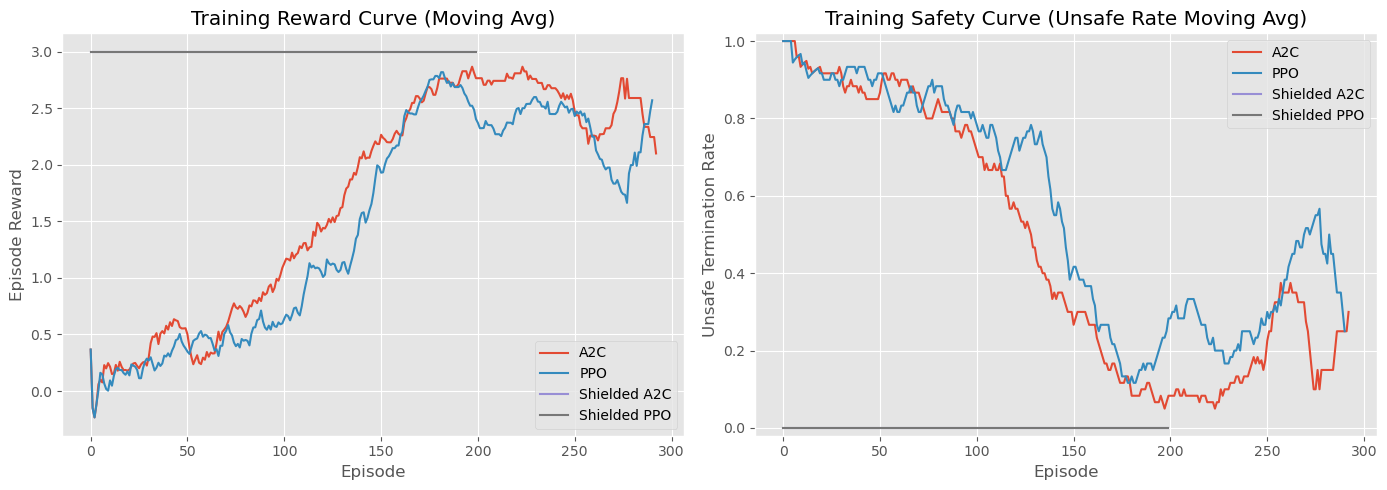

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for variant in variants:
    d = reward_mean[reward_mean['variant'] == variant]
    axes[0].plot(d['episode_idx'], d['episode_reward_smooth'], label=variant)
axes[0].set_title('Training Reward Curve (Moving Avg)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].legend()

for variant in variants:
    d = safety_mean[safety_mean['variant'] == variant]
    axes[1].plot(d['episode_idx'], d['unsafe_smooth'], label=variant)
axes[1].set_title('Training Safety Curve (Unsafe Rate Moving Avg)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Unsafe Termination Rate')
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()


In [8]:
summary = all_runs.groupby(['variant', 'seed']).agg(final_reward=('episode_reward', 'mean'), unsafe_rate=('unsafe', 'mean'), episodes=('episode_idx', 'count')).reset_index()
summary


,variant,seed,final_reward,unsafe_rate,episodes
0,A2C,0,2.038866,0.356275,247
1,A2C,1,1.451536,0.546075,293
2,A2C,2,1.692647,0.470588,272
3,PPO,0,1.549645,0.528369,282
4,PPO,1,1.558273,0.550360,278
5,PPO,2,1.435395,0.570447,291
6,Shielded A2C,0,3.000000,0.000000,200
7,Shielded A2C,1,3.000000,0.000000,200
8,Shielded A2C,2,3.000000,0.000000,200
9,Shielded PPO,0,3.000000,0.000000,200


In [9]:
summary.groupby('variant')[['final_reward', 'unsafe_rate']].mean()


,final_reward,unsafe_rate
variant,,
A2C,1.727683,0.457646
PPO,1.514438,0.549725
Shielded A2C,3.000000,0.000000
Shielded PPO,3.000000,0.000000
